In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
from random import choices, seed  # Import 'choices' and 'seed'

In [2]:
print("Checkpoint: Loading graph from file...")
G2 = nx.read_edgelist(r"/Users/periperi/Desktop/SNA-Project/astrophysics/data.txt", nodetype=int)
print("Graph loaded!")

Checkpoint: Loading graph from file...
Graph loaded!


In [3]:
def generate_ba_network(n, m0, m, random_seed=None):
    """
    Generate a scale-free network using the Barabási–Albert model.
    
    Parameters:
        n (int): Total number of nodes in the final network.
        m0 (int): Number of nodes in the initial connected network.
        m (int): Number of edges to attach from a new node to existing nodes.
        random_seed (int, optional): Seed for reproducibility. Defaults to None.
        
    Returns:
        G (networkx.Graph): Generated scale-free network.
    """
    # Set the random seed for reproducibility
    if random_seed is not None:
        seed(random_seed)  # Fix the seed for Python's random module

    # Step 1: Initialize a fully connected graph with m0 nodes
    G = nx.complete_graph(m0)
    
    # Step 2: Add new nodes one by one
    for new_node in tqdm(range(m0, n), desc="Adding nodes"):
        # Calculate degrees of existing nodes
        degrees = [G.degree(node) for node in G.nodes()]
        total_degree = sum(degrees)
        
        # Preferential attachment: Probability proportional to degree
        probabilities = [deg / total_degree for deg in degrees]
        
        # Select m nodes to connect to based on probabilities
        targets = list(range(len(G.nodes())))
        selected_nodes = []
        while len(selected_nodes) < m:
            chosen_node = choices(targets, probabilities)[0]
            if chosen_node not in selected_nodes:
                selected_nodes.append(chosen_node)
        
        # Add edges between the new node and selected nodes
        for target in selected_nodes:
            G.add_edge(new_node, target)
    
    return G

# Parameters for the BA model
total_nodes = 10000  # Final number of nodes
initial_nodes = 100  # Initial number of nodes (m0)
edges_per_new_node = 5  # Number of edges added per new node (m)
fixed_seed = 42  # Fixed random seed for reproducibility

# Generate the scale-free network
scale_free_network = generate_ba_network(total_nodes, initial_nodes, edges_per_new_node, random_seed=fixed_seed)

S = scale_free_network


Adding nodes: 100%|██████████| 9900/9900 [00:21<00:00, 465.48it/s] 


In [4]:
# Check if S is connected
if nx.is_connected(S):
    print("S is connected — the whole graph is the giant component.")
    S_gc = S  # No need to extract anything
else:
    print("S is not connected — extracting the giant component.")
    largest_cc_S = max(nx.connected_components(S), key=len)
    S_gc = S.subgraph(largest_cc_S).copy()

# Print stats about the giant component
print(f"Giant Component of S — Nodes: {S_gc.number_of_nodes()}, Edges: {S_gc.number_of_edges()}")


S is connected — the whole graph is the giant component.
Giant Component of S — Nodes: 10000, Edges: 54450


In [5]:
# Check if G1 is connected
if nx.is_connected(G2):
    print("G2 is connected — the whole graph is the giant component.")
    G2_gc = G2
else:
    print("G2 is not connected — extracting the giant component.")
    largest_cc_G2 = max(nx.connected_components(G2), key=len)
    G2_gc = G2.subgraph(largest_cc_G2).copy()

# Print stats
print(f"Giant Component of G2 — Nodes: {G2_gc.number_of_nodes()}, Edges: {G2_gc.number_of_edges()}")


G2 is not connected — extracting the giant component.
Giant Component of G2 — Nodes: 14845, Edges: 119652


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def analyze_graph(G, name="Graph"):
    print(f"\n--- {name} ---")

    # 1. Number of nodes and edges
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    print(f"Nodes: {num_nodes}")
    print(f"Edges: {num_edges}")

    # 2. Average degree
    avg_degree = sum(dict(G.degree()).values()) / num_nodes
    print(f"Average Degree: {avg_degree:.4f}")

    # 3. Degree distribution
    degrees = [deg for node, deg in G.degree()]
    plt.figure(figsize=(8, 5))
    plt.hist(degrees, bins=100, log=True, color='skyblue', edgecolor='black')
    plt.title(f"Degree Distribution - {name}")
    plt.xlabel("Degree")
    plt.ylabel("Frequency (log scale)")
    plt.grid(True)
    plt.show()

    # 4. Average local clustering coefficient
    clustering_coeff = nx.average_clustering(G)
    print(f"Average Clustering Coefficient (Local): {clustering_coeff:.4f}")

    # 4b. Global clustering coefficient (Transitivity)
    transitivity = nx.transitivity(G)
    print(f"Global Clustering Coefficient (Transitivity): {transitivity:.4f}")

    # 5. Diameter (on the largest connected component)
    if nx.is_connected(G):
        diameter = nx.diameter(G)
        print(f"Diameter: {diameter}")
        avg_path_len = nx.average_shortest_path_length(G)
        print(f"Average Shortest Path Length: {avg_path_len:.4f}")
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_lcc = G.subgraph(largest_cc).copy()
        diameter = nx.diameter(G_lcc)
        print(f"Diameter (Largest Connected Component): {diameter}")
        avg_path_len = nx.average_shortest_path_length(G_lcc)
        print(f"Average Shortest Path Length (Largest Connected Component): {avg_path_len:.4f}")



--- ASTROPHYSICS (G2) ---
Nodes: 14845
Edges: 119652
Average Degree: 16.1202


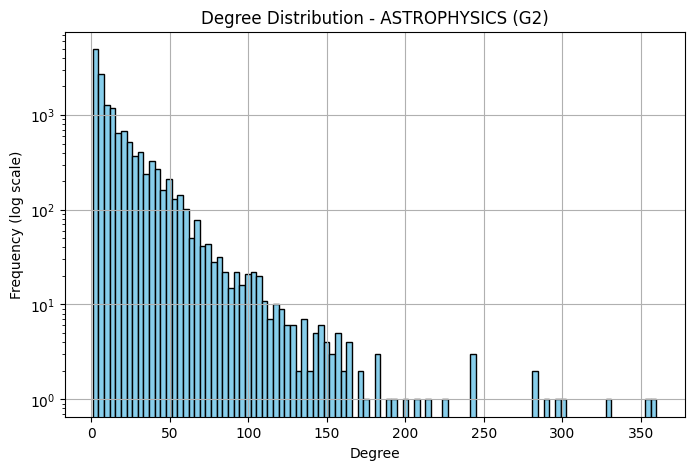

Average Clustering Coefficient (Local): 0.6696
Global Clustering Coefficient (Transitivity): 0.4253
Diameter: 14
Average Shortest Path Length: 4.7980


In [7]:
analyze_graph(G2_gc, name="ASTROPHYSICS (G2)")



📊 Centrality Measures for ASTROPHYSICS
Computing Betweenness Centrality...
Computing Eigenvector Centrality...

--- Degree Centrality ---
Mean: 0.0011
Std Dev: 0.0015
Max: 0.0243
Min: 0.0001
Top 5 Nodes:
Node 789 → 0.0243
Node 274 → 0.0238
Node 298 → 0.0222
Node 790 → 0.0201
Node 793 → 0.0199


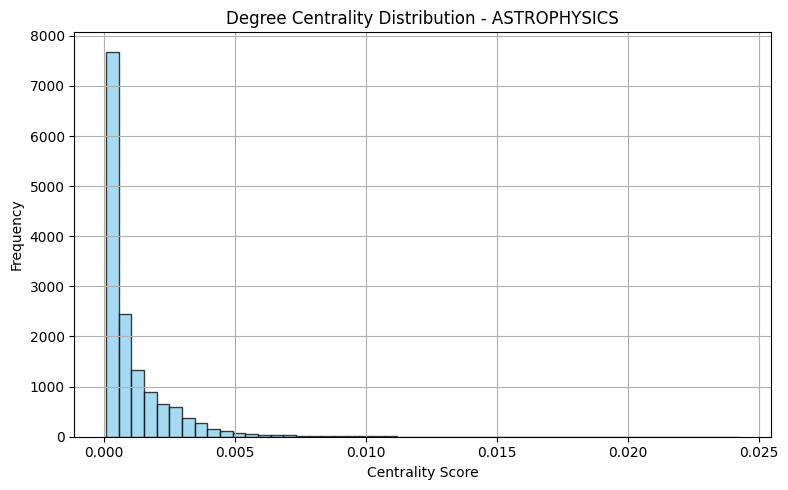


--- Betweenness Centrality ---
Mean: 0.0003
Std Dev: 0.0008
Max: 0.0214
Min: 0.0000
Top 5 Nodes:
Node 274 → 0.0214
Node 298 → 0.0196
Node 724 → 0.0194
Node 719 → 0.0155
Node 789 → 0.0151


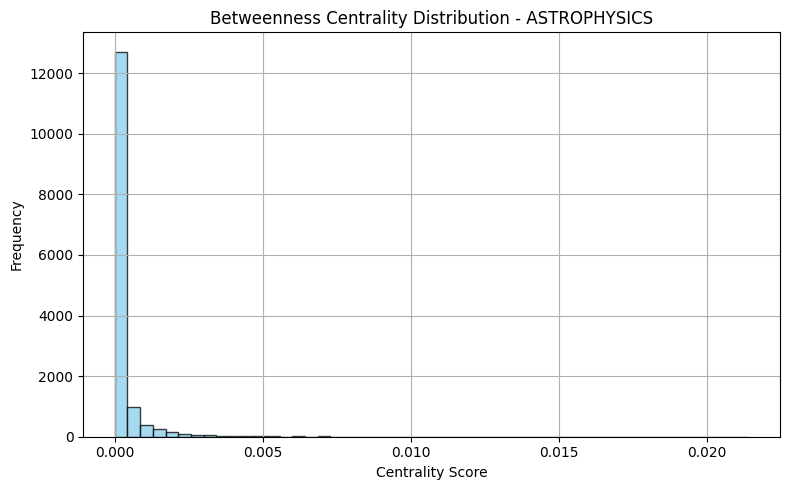


--- Closeness Centrality ---
Mean: 0.2136
Std Dev: 0.0318
Max: 0.3148
Min: 0.1050
Top 5 Nodes:
Node 789 → 0.3148
Node 274 → 0.3139
Node 298 → 0.3126
Node 793 → 0.3118
Node 790 → 0.3112


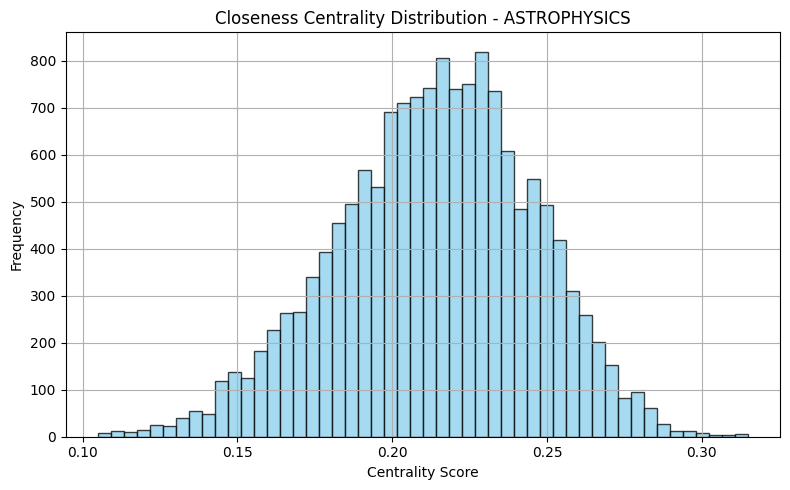


--- Eigenvector Centrality ---
Mean: 0.0021
Std Dev: 0.0079
Max: 0.1351
Min: 0.0000
Top 5 Nodes:
Node 789 → 0.1351
Node 1017 → 0.1290
Node 1400 → 0.1222
Node 790 → 0.1196
Node 298 → 0.1187


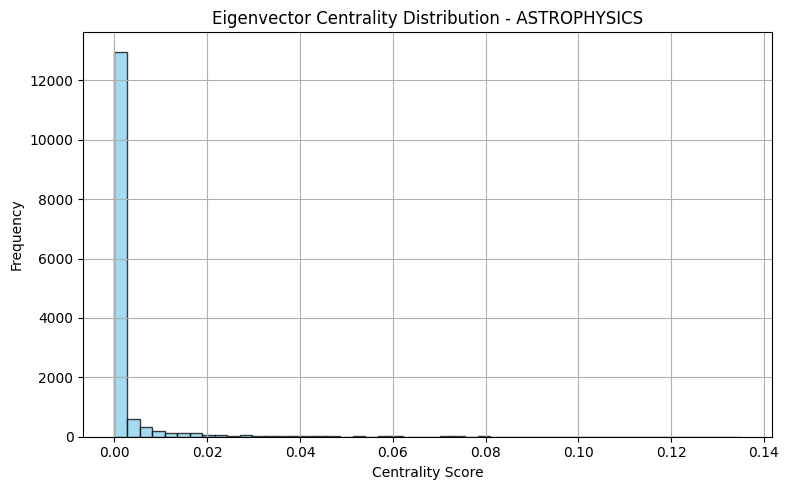

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def centrality_analysis(G, label="ASTROPHYSICS"):
    print(f"\n📊 Centrality Measures for {label}")

    # 1. Degree Centrality
    degree_centrality = nx.degree_centrality(G)
    
    # 2. Betweenness Centrality
    print("Computing Betweenness Centrality...")
    betweenness_centrality = nx.betweenness_centrality(G)
    
    # 3. Closeness Centrality
    closeness_centrality = nx.closeness_centrality(G)
    
    # 4. Eigenvector Centrality
    print("Computing Eigenvector Centrality...")
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

    centralities = {
        "Degree": degree_centrality,
        "Betweenness": betweenness_centrality,
        "Closeness": closeness_centrality,
        "Eigenvector": eigenvector_centrality
    }

    # Summary Stats and Plots
    for name, cent in centralities.items():
        values = list(cent.values())
        print(f"\n--- {name} Centrality ---")
        print(f"Mean: {np.mean(values):.4f}")
        print(f"Std Dev: {np.std(values):.4f}")
        print(f"Max: {np.max(values):.4f}")
        print(f"Min: {np.min(values):.4f}")
        top_nodes = sorted(cent.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"Top 5 Nodes:")
        for node, val in top_nodes:
            print(f"Node {node} → {val:.4f}")

        # Plot distribution
        plt.figure(figsize=(8, 5))
        plt.hist(values, bins=50, color='skyblue', edgecolor='black', alpha=0.75)
        plt.title(f"{name} Centrality Distribution - {label}")
        plt.xlabel("Centrality Score")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Run centrality analysis on G2_gc
centrality_analysis(G2_gc)